# Neural Network Test Run (9)

In [1]:
%%capture
# %%capture prevents this cell from printing a ton of STDERR stuff to the screen

## First, check to see if lightning is installed, if not, install it.
##
## NOTE: If you **do** need to install something, just know that you may need to
##       restart your session for python to find the new module(s).
##
##       To restart your session:
##       - In Google Colab, click on the "Runtime" menu and select
##         "Restart Session" from the pulldown menu
##       - In a local jupyter notebook, click on the "Kernel" menu and select
##         "Restart Kernel" from the pulldown menu
import pip
try:
  __import__("lightning")
except ImportError:
  pip.main(['install', "lightning"])

In [2]:
import torch 
import torch.nn as nn 

from torch.optim import Adam 
from torch.distributions.uniform import Uniform 
from torch.utils.data import TensorDataset, DataLoader 

import lightning as L 

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
## create the training data for the neural network. One-hot-encode them.
inputs = torch.tensor([[1., 0., 0., 0.], # 'Troll 2' one-hot-encoded
                       [0., 1., 0., 0.], # 'is' one-hot-encoded
                       [0., 0., 1., 0.], # 'great' one-hot-encoded
                       [0., 0., 0., 1.]]) # 'Gymkata' one-hot-encoded

labels = torch.tensor([[0., 1., 0., 0.], # "Troll 2" is followed by "is"
                       [0., 0., 1., 0.], # "is" is followed by "great"
                       [0., 0., 0., 1.], # "great" isn't followed by anything, but we'll pretend it was followed by "Gymkata"
                       [0., 1., 0., 0.]]) # "Gymkata", just like "Troll 2", is followed by "is".

In [4]:
inputs

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])

In [5]:
labels

tensor([[0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.]])

In [6]:
dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

In [7]:
dataset

In [8]:
dataloader

In [9]:
class WordEmbeddingFromScratch(L.LightningModule):
  
  def __init__(self):
    
    super().__init__()
    
    L.seed_everything(42)
    
    min_value = -0.5
    max_value = 0.5
    
    # word 1
    self.input1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
    self.input1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
    
    # word 2
    self.input2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
    self.input2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
    
    # word 3
    self.input3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
    self.input3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

    # word 4
    self.input4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
    self.input4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
    
    
    # Initialize the weights that come OUT of the hidden layer to the "output".
    ## NOTE: Again, we are excluding bias terms. This time, we exclude them simply because
    ##       we do not need them.
    
    # word 1
    self.output1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
    self.output1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
    
    # word 2
    self.output2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
    self.output2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

    # word 3
    self.output3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
    self.output3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

    # word 4
    self.output4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
    self.output4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
    
    
    self.loss = nn.CrossEntropyLoss()
  
  def forward(self, input):
    input = input[0]
    
    inputs_to_top_hidden = ((input[0] * self.input1_w1) + 
                            (input[1] * self.input2_w1) + 
                            (input[2] * self.input3_w1) +
                            (input[3] * self.input4_w1))
    
    ## ...then, for the bottom node in the hidden layer,
    ## we multiply each input by its weight,
    ## and then calculate the sum of those products.
    inputs_to_bottom_hidden = ((input[0] * self.input1_w2) + 
                               (input[1] * self.input2_w2) + 
                               (input[2] * self.input3_w2) + 
                               (input[3] * self.input4_w2))
    
    ## Now, in theory, we could run inputs_to_top_hidden and inputs_to_bottom_hidden through linear activation functions, but the outputs would be the exact same as in the inputs cause IDENTIFY FUNCTION.
    ## So we can just skip that step and instead compute the 4 output values from the 2 nodes in hidden layer by summing the products of the hidden layer values and a pair of weights for each output.
    output1 = ((inputs_to_top_hidden * self.output1_w1) + 
               (inputs_to_bottom_hidden * self.output1_w2))
    
    output2 = ((inputs_to_top_hidden * self.output2_w1) + 
               (inputs_to_bottom_hidden * self.output2_w2))
    
    output3 = ((inputs_to_top_hidden * self.output3_w1) + 
               (inputs_to_bottom_hidden * self.output3_w2))
    
    output4 = ((inputs_to_top_hidden * self.output4_w1) + 
               (inputs_to_bottom_hidden * self.output4_w2))
    
    # Concatenate the 4 output tensors so we run them through SoftMax.
    # However, because they are tensors (and have gradients attached to them),
    ## we can't just combine them in a simple list like this...
    # output_values = [output1, output2, output3, output4] ## THIS WILL NOT WORK
    ## ...because that would strip off the gradients.
    ## Instead, we use torch.stack(), which retains the gradients.
    
    output_presoftmax = torch.stack([output1, output2, output3, output4])
    return(output_presoftmax)
  
  def configure_optimizers(self):
    # configure_optimizers() configures the optimizer we want to use for backpropagation.

    return Adam(self.parameters(), lr=0.1) # lr=0.1 sets the learning rate to 0.1


  def training_step(self, batch):
    # training_step() takes a step of gradient descent.

    input_i, label_i = batch # collect input
    output_i = self.forward(input_i) # run input through the neural network
    loss = self.loss(output_i, label_i[0]) ## loss = cross entropy

    return loss

In [10]:
modelFromScratch = WordEmbeddingFromScratch()

print("Before optimization, the parameters are...")
for name, param in modelFromScratch.named_parameters():
    print(name, torch.round(param.data, decimals=2))

Before optimization, the parameters are...
input1_w1 tensor(0.3800)
input1_w2 tensor(0.4200)
input2_w1 tensor(-0.1200)
input2_w2 tensor(0.4600)
input3_w1 tensor(-0.1100)
input3_w2 tensor(0.1000)
input4_w1 tensor(-0.2400)
input4_w2 tensor(0.2900)
output1_w1 tensor(0.4400)
output1_w2 tensor(-0.3700)
output2_w1 tensor(0.4300)
output2_w2 tensor(0.0900)
output3_w1 tensor(0.3700)
output3_w2 tensor(0.0700)
output4_w1 tensor(0.2400)
output4_w2 tensor(-0.0700)


In [11]:
data = {
    "w1": [modelFromScratch.input1_w1.item(), ## item() pulls out the tensor value as a float
           modelFromScratch.input2_w1.item(),
           modelFromScratch.input3_w1.item(),
           modelFromScratch.input4_w1.item()],
    "w2": [modelFromScratch.input1_w2.item(),
           modelFromScratch.input2_w2.item(),
           modelFromScratch.input3_w2.item(),
           modelFromScratch.input4_w2.item()],
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.382269,0.415004,Troll2,input1
1,-0.117136,0.459306,is,input2
2,-0.109552,0.100895,great,input3
3,-0.243428,0.293641,Gymkata,input4


findfont: Failed to find font weight semibold, now using 700.


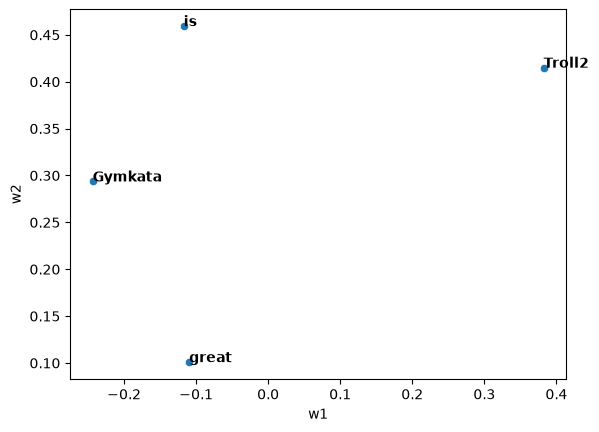

In [12]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token that each dot represents to the graph
# Troll 2
plt.text(df.w1[0], df.w2[0], df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# Gymkata
plt.text(df.w1[3], df.w2[3], df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [13]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(modelFromScratch, train_dataloaders=dataloader)

/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consid

Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 91.77it/s, v_num=2] 


In [14]:
print("After optimization, the parameters are...")
for name, param in modelFromScratch.named_parameters():
    print(name, torch.round(param.data, decimals=2))

After optimization, the parameters are...
input1_w1 tensor(2.0200)
input1_w2 tensor(1.9400)
input2_w1 tensor(-2.1800)
input2_w2 tensor(2.3200)
input3_w1 tensor(-2.0300)
input3_w2 tensor(-2.1600)
input4_w1 tensor(1.6900)
input4_w2 tensor(1.8900)
output1_w1 tensor(1.2600)
output1_w2 tensor(-1.7700)
output2_w1 tensor(3.0800)
output2_w2 tensor(1.3600)
output3_w1 tensor(-1.5800)
output3_w2 tensor(0.8800)
output4_w1 tensor(-1.5700)
output4_w2 tensor(-3.2900)


In [15]:
data = {
    "w1": [modelFromScratch.input1_w1.item(), ## item() pulls out the tensor value as a float
           modelFromScratch.input2_w1.item(),
           modelFromScratch.input3_w1.item(),
           modelFromScratch.input4_w1.item()],
    "w2": [modelFromScratch.input1_w2.item(),
           modelFromScratch.input2_w2.item(),
           modelFromScratch.input3_w2.item(),
           modelFromScratch.input4_w2.item()],
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,2.015900,1.941387,Troll2,input1
1,-2.182003,2.318647,is,input2
2,-2.028374,-2.161837,great,input3
3,1.691302,1.894240,Gymkata,input4


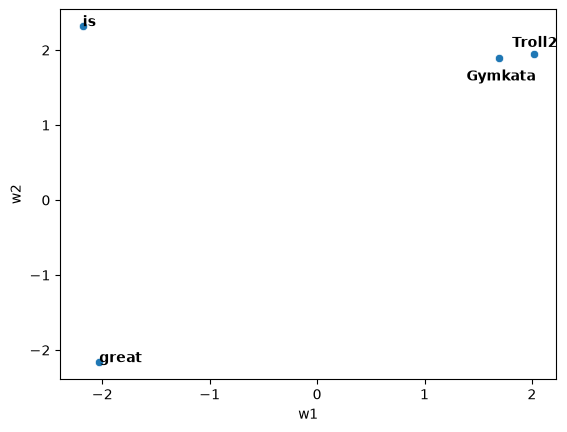

In [16]:
sns.scatterplot(data=df, x="w1", y="w2")

## NOTE: For Troll2 and and Gymkata, we're adding offsets to where to print the tokens because otherwise
## they will be so close to each other that they will overlap and be unreadable.

## Troll 2
plt.text(df.w1[0]-0.2, df.w2[0]+0.1, df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## gymkata
plt.text(df.w1[3]-0.3, df.w2[3]-0.3, df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [17]:
## Let's see what the model predicts

## First, let's create a softmax object...
softmax = nn.Softmax(dim=0) ## dim=0 applies softmax to rows, dim=1 applies softmax to columns

# Note that the forward() method is flattening the input, i.e., input = input[0].
# Because we are stacking 4 scalar values, the shape of the output vector 
# is a 1D tensor with shape (4), i.e., [val1, val2, val3, val4]:
# output_presoftmax = torch.stack([output1, output2, output3, output4])
# Therefore dim=0 applies softmax to the only dimension (the list of values)

## Now let's...

## print the predictions for "Troll2"
print(torch.round(softmax(modelFromScratch(torch.tensor([[1., 0., 0., 0.]]))),
                  decimals=2))

## print the predictions for "is"
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 1., 0., 0.]]))),
                  decimals=2))

## print the predictions for "great"
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 0., 1., 0.]]))),
                  decimals=2))

## print the predictions for "Gymkata"
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 0., 0., 1.]]))),
                  decimals=2))

tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)
tensor([0., 0., 1., 0.], grad_fn=<RoundBackward1>)
tensor([0., 0., 0., 1.], grad_fn=<RoundBackward1>)
tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)


## Build and train a Word Embedding Unit using nn.Linear()

* Now that we can make a Word Embedding network from scratch, let's simplify the code using nn.Linear(). nn.Linear() will make initialzing the tensors super easy and the math we do in the forward() step will also be much simpler.

In [25]:
class WordEmbeddingWithLinear(L.LightningModule):
  
  def __init__(self):
    super().__init__()
    
    L.seed_everything(seed=42)
    
    self.input_to_hidden = nn.Linear(in_features=4, out_features=2, bias=False)
    
    self.hidden_to_output = nn.Linear(in_features=2, out_features=4, bias=False)
    
    self.loss = nn.CrossEntropyLoss()
    
  
  def forward(self, input):
    hidden = self.input_to_hidden(input)
    
    output_values = self.hidden_to_output(hidden)
    
    return(output_values)
  

  def configure_optimizers(self):
    # this configures the optimizer we want to use for backpropagation.
    return Adam(self.parameters(), lr=0.1)
  
  
  def training_step(self, batch):
    # take a step during gradient descent.
    input_i, label_i = batch # collect input
    output_i = self.forward(input_i) # run input through the neural network
    loss = self.loss(output_i, label_i) ## loss = cross entropy

    return loss

In [26]:
modelLinear = WordEmbeddingWithLinear()

print("Before optimization, the parameters are...")
for name, param in modelLinear.named_parameters():
    print(name, torch.round(param.data, decimals=2))

Before optimization, the parameters are...
input_to_hidden.weight tensor([[ 0.3800,  0.4200, -0.1200,  0.4600],
        [-0.1100,  0.1000, -0.2400,  0.2900]])
hidden_to_output.weight tensor([[ 0.6200, -0.5200],
        [ 0.6100,  0.1300],
        [ 0.5200,  0.1000],
        [ 0.3400, -0.1000]])


In [27]:
data = {
    ## NOTE: Unlike before, when we called item() on each individual
    ##       Weight, now that we are using nn.Linear, we access the
    ##       Weights with ".weight". We then have to remove the gradients
    ##       associated with each Weight, so we also call .detach().
    ##       Lastly, we then convert the tensor to a numpy array with
    ##       numpy().
    "w1": modelLinear.input_to_hidden.weight.detach()[0].numpy(), # [0] = Weights to top activation function
    "w2": modelLinear.input_to_hidden.weight.detach()[1].numpy(), # [1] = Weights to bottom activation function
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.382269,-0.109552,Troll2,input1
1,0.415004,0.100895,is,input2
2,-0.117136,-0.243428,great,input3
3,0.459306,0.293641,Gymkata,input4


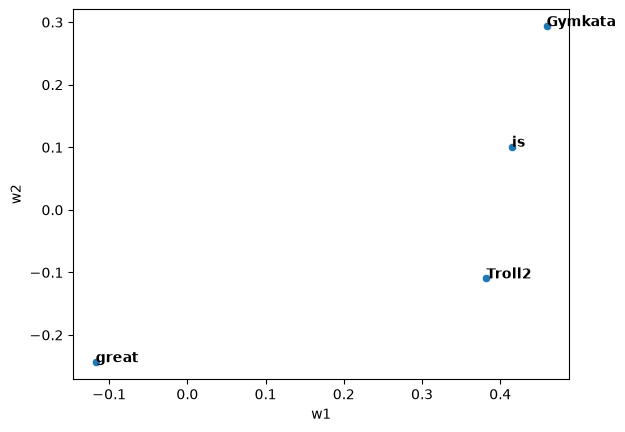

In [28]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token each dot represents to the graph

## Troll 2
plt.text(df.w1[0], df.w2[0], df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
## is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
## great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

## Gymkata
plt.text(df.w1[3], df.w2[3], df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [29]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(modelLinear, train_dataloaders=dataloader)

/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 130.33it/s, v_num=4]


In [30]:
print("After optimization, the parameters are...")
for name, param in modelLinear.named_parameters():
    print(name, param.data)

After optimization, the parameters are...
input_to_hidden.weight tensor([[ 2.5105, -1.0177, -1.9742,  2.4355],
        [-0.0688,  2.4824, -1.8190, -0.2228]])
hidden_to_output.weight tensor([[-0.3022, -1.0102],
        [ 3.2008, -0.3850],
        [-0.6694,  2.1814],
        [-2.6841, -2.9578]])


In [31]:
data = {
    "w1": modelLinear.input_to_hidden.weight.detach()[0].numpy(),
    "w2": modelLinear.input_to_hidden.weight.detach()[1].numpy(),
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,2.510462,-0.068828,Troll2,input1
1,-1.017656,2.482449,is,input2
2,-1.974170,-1.818986,great,input3
3,2.435530,-0.222820,Gymkata,input4


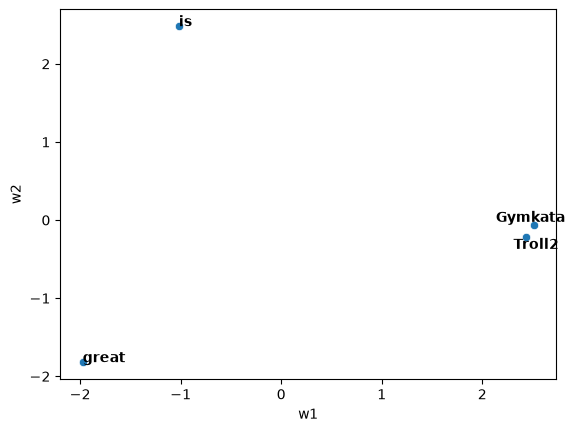

In [32]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token each dot represents to the graph
## NOTE: For Troll2 and and Gymkata, we're adding offsets to where to print the tokens because otherwise
## they will be so close to each other that they will overlap and be unreadable.

# Troll 2
plt.text(df.w1[0]-0.2, df.w2[0]-0.3, df.token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# is
plt.text(df.w1[1], df.w2[1], df.token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

# Gymkata
plt.text(df.w1[3]-0.3, df.w2[3]+0.2, df.token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [33]:
## Let's see what the model predicts
softmax = nn.Softmax(dim=1) ## dim=0 applies softmax to rows, dim=1 applies softmax to columns

# Unlike the modelFromScratch model, nn.Linear produces a 2D tensor with shape (1, 4),
# preserving the batch dimension: [[val1, val2, val3, val4]].
# Since the classes are arranged across the columns (Dimension 1), we use dim=1 
# to squash the values across the row so they sum to 1.

print(torch.round(softmax(modelLinear(torch.tensor([[1., 0., 0., 0.]]))), decimals=2)) ## print the predictions for "Troll2"
print(torch.round(softmax(modelLinear(torch.tensor([[0., 1., 0., 0.]]))), decimals=2)) ## print the predictions for "is"
print(torch.round(softmax(modelLinear(torch.tensor([[0., 0., 1., 0.]]))), decimals=2)) ## print the predictions for "great"
print(torch.round(softmax(modelLinear(torch.tensor([[0., 0., 0., 1.]]))), decimals=2)) ## print the predictions for "Gymkata"

tensor([[0., 1., 0., 0.]], grad_fn=<RoundBackward1>)
tensor([[0., 0., 1., 0.]], grad_fn=<RoundBackward1>)
tensor([[0., 0., 0., 1.]], grad_fn=<RoundBackward1>)
tensor([[0., 1., 0., 0.]], grad_fn=<RoundBackward1>)


In [34]:
modelLinear.input_to_hidden.weight

Parameter containing:
tensor([[ 2.5105, -1.0177, -1.9742,  2.4355],
        [-0.0688,  2.4824, -1.8190, -0.2228]], requires_grad=True)

In [35]:
##  NOTE: We have to transpose the original embedding values (from w1 and w2) for nn.Embedding()
##        and we do this with adding a '.T' to modelLinear.input_to_hidden.weight.T
word_embeddings = nn.Embedding.from_pretrained(modelLinear.input_to_hidden.weight.T)

In [36]:
word_embeddings.weight

Parameter containing:
tensor([[ 2.5105, -0.0688],
        [-1.0177,  2.4824],
        [-1.9742, -1.8190],
        [ 2.4355, -0.2228]])

In [37]:
word_embeddings

Embedding(4, 2)

In [39]:
word_embeddings(torch.tensor(0))

tensor([ 2.5105, -0.0688])

In [40]:
# ...or we can create a dictionary and access the embedding values with words or tokens instead.
vocab = {'Troll2': 0,
         'is': 1,
         'great': 2,
         'Gymkata': 3}

In [41]:
word_embeddings(torch.tensor(vocab['Troll2']))

tensor([ 2.5105, -0.0688])

In [42]:
word_embeddings(torch.tensor(vocab['Gymkata']))

tensor([ 2.4355, -0.2228])